
# OT mapping estimation for domain adaptation

This example presents how to use MappingTransport to estimate at the same
time both the coupling transport and approximate the transport map with either
a linear or a kernelized mapping as introduced in [8].

[8] M. Perrot, N. Courty, R. Flamary, A. Habrard,
"Mapping estimation for discrete optimal transport",
Neural Information Processing Systems (NIPS), 2016.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Authors: Remi Flamary <remi.flamary@unice.fr>
#          Stanislas Chambon <stan.chambon@gmail.com>
#
# License: MIT License

# sphinx_gallery_thumbnail_number = 2

import numpy as np
import matplotlib.pylab as pl
import ot
from Utils.joint_OT_mapping_linear_classreg import MappingTransport

## Generate data



In [3]:
n_source_samples = 100
n_target_samples = 100
theta = 2 * np.pi / 20
noise_level = 0.1

Xs, ys = ot.datasets.make_data_classif("gaussrot", n_source_samples, nz=noise_level)
Xs_new, _ = ot.datasets.make_data_classif("gaussrot", n_source_samples, nz=noise_level)
Xt, yt = ot.datasets.make_data_classif(
    "gaussrot", n_target_samples, theta=theta, nz=noise_level
)

# one of the target mode changes its variance (no linear mapping)
Xt[yt == 2] *= 3
Xt = Xt + 4

## Plot data



Text(0.5, 1.0, 'Source and target distributions')

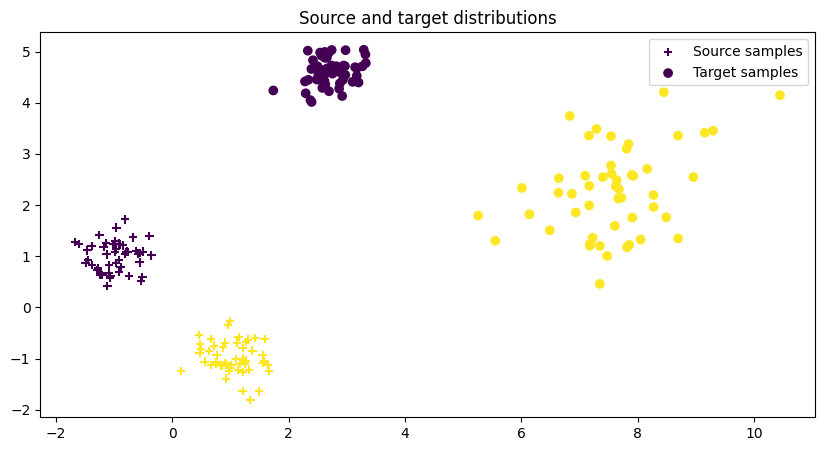

In [4]:
pl.figure(1, (10, 5))
pl.clf()
pl.scatter(Xs[:, 0], Xs[:, 1], c=ys, marker="+", label="Source samples")
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples")
pl.legend(loc=0)
pl.title("Source and target distributions")

## Instantiate the different transport algorithms and fit them



In [7]:
# MappingTransport with linear kernel
ot_mapping_linear = MappingTransport(
    kernel="linear", mu=1e0, eta=1e-8, bias=True, max_iter=20, verbose=True
)

ot_mapping_linear.fit(Xs=Xs, ys=ys, Xt=Xt, yt=yt)

# for original source samples, transform applies barycentric mapping
transp_Xs_linear = ot_mapping_linear.transform(Xs=Xs)

# for out of source samples, transform applies the linear mapping
transp_Xs_linear_new = ot_mapping_linear.transform(Xs=Xs_new)


# MappingTransport with gaussian kernel
ot_mapping_gaussian = MappingTransport(
    kernel="gaussian", eta=1e-5, mu=1e-1, bias=True, sigma=1, max_iter=10, verbose=True
)
ot_mapping_gaussian.fit(Xs=Xs, ys=ys, Xt=Xt, yt=yt)

# for original source samples, transform applies barycentric mapping
transp_Xs_gaussian = ot_mapping_gaussian.transform(Xs=Xs)

# for out of source samples, transform applies the gaussian mapping
transp_Xs_gaussian_new = ot_mapping_gaussian.transform(Xs=Xs_new)

It.  |Loss        |Delta loss
--------------------------------
    0|4.080498e+03|0.000000e+00
    1|4.065145e+03|-3.762472e-03
    2|4.064622e+03|-1.287038e-04
    3|4.064417e+03|-5.044820e-05
    4|4.064279e+03|-3.399792e-05
    5|4.064195e+03|-2.069351e-05
    6|4.064130e+03|-1.602752e-05
    7|4.064105e+03|-5.945549e-06
Barycentric mapping
Linear mapping
It.  |Loss        |Delta loss
--------------------------------
    0|4.101840e+02|0.000000e+00
    1|4.054597e+02|-1.151763e-02
    2|4.052718e+02|-4.634912e-04
    3|4.051989e+02|-1.797243e-04
    4|4.051561e+02|-1.056601e-04
    5|4.051277e+02|-7.021811e-05
    6|4.051054e+02|-5.487132e-05
    7|4.050882e+02|-4.248063e-05
    8|4.050746e+02|-3.357595e-05
    9|4.050627e+02|-2.938487e-05
   10|4.050530e+02|-2.392915e-05
Barycentric mapping
Gaussian mapping


## Plot transported samples



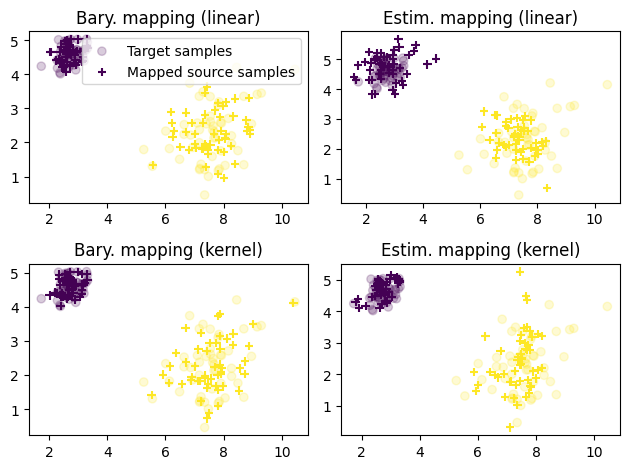

In [8]:
pl.figure(2)
pl.clf()
pl.subplot(2, 2, 1)
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_linear[:, 0],
    transp_Xs_linear[:, 1],
    c=ys,
    marker="+",
    label="Mapped source samples",
)
pl.title("Bary. mapping (linear)")
pl.legend(loc=0)

pl.subplot(2, 2, 2)
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_linear_new[:, 0],
    transp_Xs_linear_new[:, 1],
    c=ys,
    marker="+",
    label="Learned mapping",
)
pl.title("Estim. mapping (linear)")

pl.subplot(2, 2, 3)
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_gaussian[:, 0],
    transp_Xs_gaussian[:, 1],
    c=ys,
    marker="+",
    label="barycentric mapping",
)
pl.title("Bary. mapping (kernel)")

pl.subplot(2, 2, 4)
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples", alpha=0.2)
pl.scatter(
    transp_Xs_gaussian_new[:, 0],
    transp_Xs_gaussian_new[:, 1],
    c=ys,
    marker="+",
    label="Learned mapping",
)
pl.title("Estim. mapping (kernel)")
pl.tight_layout()

pl.show()